In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix, precision_score
import seaborn as sns

In [4]:
df = pd.read_csv('spam.csv', encoding = 'latin-1')

In [5]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df_nueva_data = df[['v1', 'v2']]
df_nueva_data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df_nueva_data = df_nueva_data.rename(
    columns = {
        'v1': 'categoria',
        'v2': 'descripcion'
    }
)

In [8]:
df_nueva_data.head(5)

,categoria,descripcion
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
X = df_nueva_data['descripcion']
y = df_nueva_data['categoria']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 19)

In [11]:
vectorizador = CountVectorizer()
X_train_vec = vectorizador.fit_transform(X_train)
X_test_vec = vectorizador.transform(X_test)

In [12]:
modelo = MultinomialNB()
modelo.fit(X_train_vec, y_train)

MultinomialNB()

In [13]:
y_pred = modelo.predict(X_test_vec)
print(y_pred)

['ham' 'spam' 'ham' ... 'spam' 'spam' 'ham']


In [14]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9856459330143541


In [15]:
f1 = f1_score(y_test, y_pred, pos_label = 'spam')
print(f1)

0.9504132231404959


In [16]:
report = classification_report(y_test, y_pred, target_names=['spam', 'ham'])
print(report)

              precision    recall  f1-score   support

        spam       0.99      1.00      0.99      1425
         ham       0.97      0.93      0.95       247

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672



# MÉTRICAS Y GRÁFICAS DE EVALUACIÓN

In [25]:
# Calcular todas las métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='spam')
recall = recall_score(y_test, y_pred, pos_label='spam')
f1 = f1_score(y_test, y_pred, pos_label='spam')

print('===============================================')
print('MÉTRICAS DEL MODELO')
print('===============================================')
print(f'Accuracy:{accuracy:.4f}')
print(f'Precision:{precision:.4f}')
print(f'Recall:{recall:.4f}')
print(f'F1-Score:{f1:.4f}')
print('===============================================')

MÉTRICAS DEL MODELO
Accuracy:  0.9856
Precision: 0.9705
Recall:    0.9312
F1-Score:  0.9504


In [29]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])
print('Matriz de Confusión:')
print(cm)

Matriz de Confusión:
[[1418    7]
 [  17  230]]


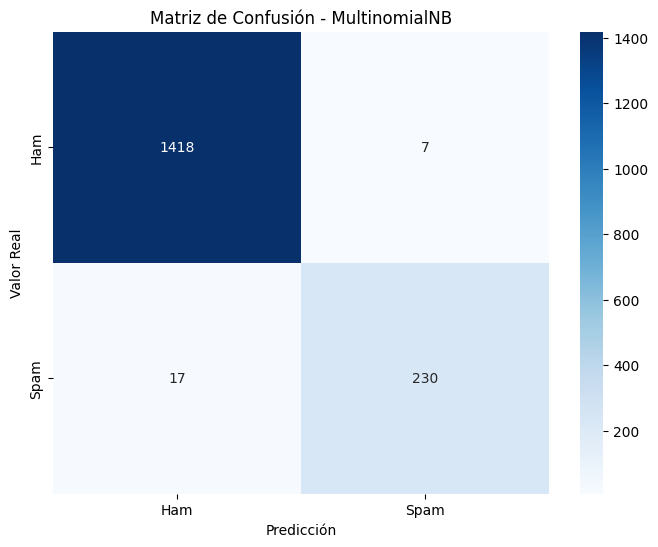

In [19]:
# Gráfica 1: Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - MultinomialNB')
plt.show()

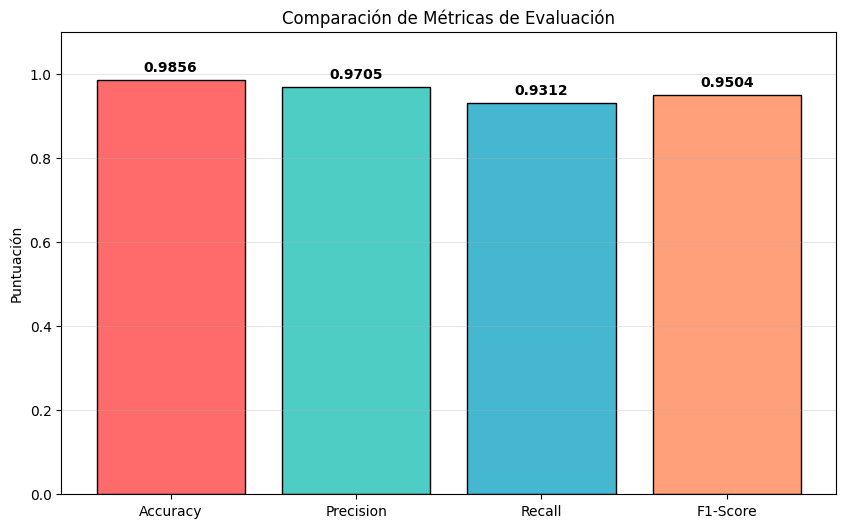

In [28]:
# Gráfica 2: Comparación de Métricas
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores = [accuracy, precision, recall, f1]

plt.figure(figsize=(10, 6))
plt.bar(metricas, valores, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], edgecolor='black')
plt.ylabel('Puntuación')
plt.title('Comparación de Métricas de Evaluación')
plt.ylim(0, 1.1)
for i, v in enumerate(valores):
  plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

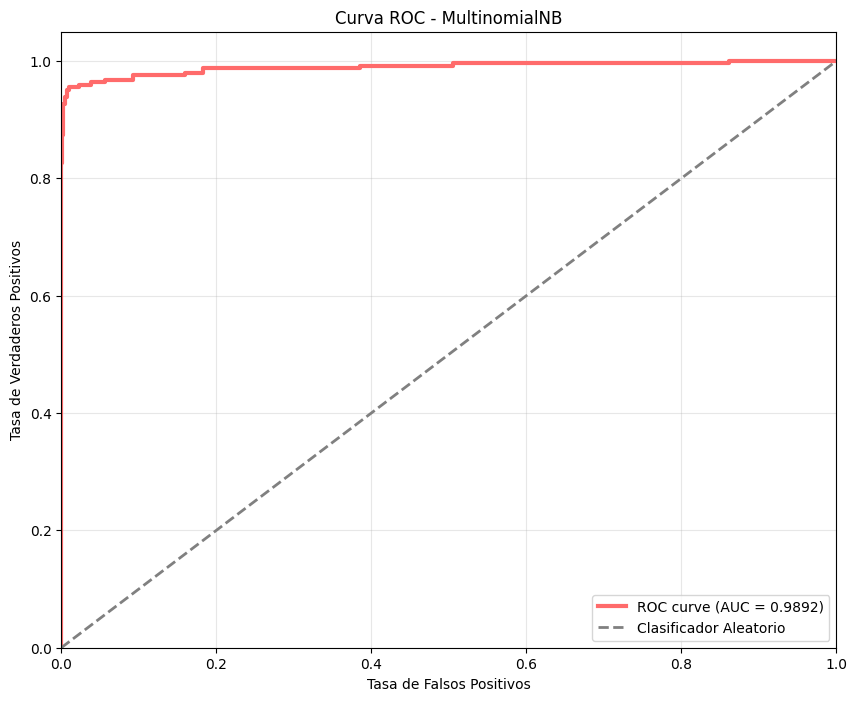

AUC Score: 0.9892


In [21]:
# Gráfica 3: Curva ROC
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)
y_pred_proba = modelo.predict_proba(X_test_vec)
y_pred_proba_spam = y_pred_proba[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_proba_spam)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='#FF6B6B', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - MultinomialNB')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'AUC Score: {roc_auc:.4f}')

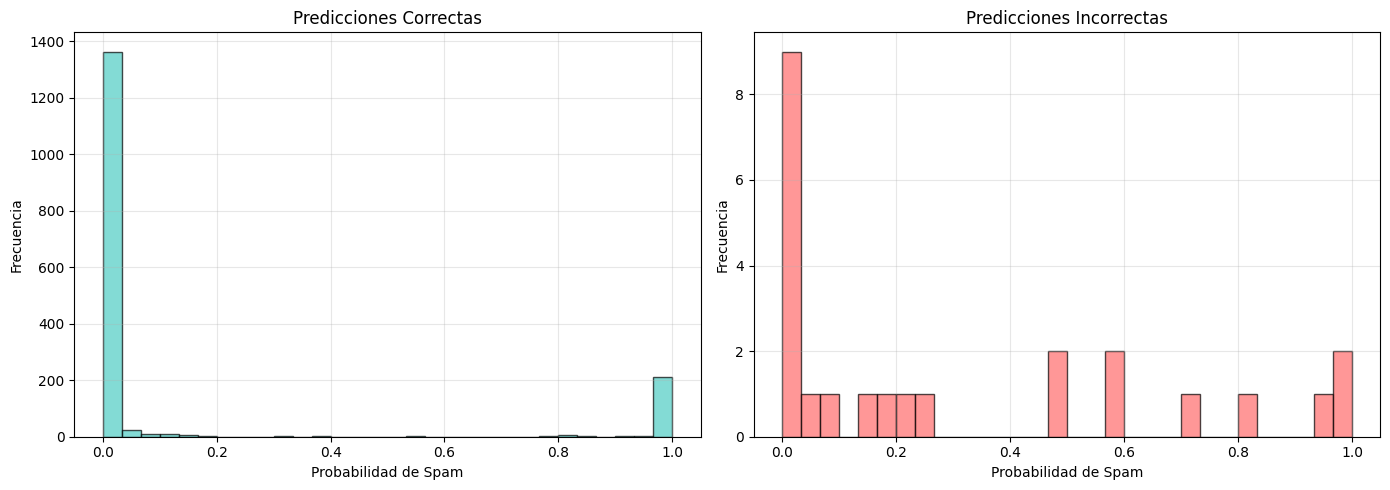

In [22]:
# Gráfica 4: Distribución de Probabilidades
predicciones_correctas = y_pred == y_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_pred_proba_spam[predicciones_correctas], bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Probabilidad de Spam')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Predicciones Correctas')
axes[0].grid(alpha=0.3)

axes[1].hist(y_pred_proba_spam[~predicciones_correctas], bins=30, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Probabilidad de Spam')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Predicciones Incorrectas')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# Resumen de resultados
print('===============================================')
print('RESUMEN DE EVALUACIÓN - MULTINOMIALNB')
print('===============================================')
print(f'Accuracy:{accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Precision:{precision:.4f} ({precision*100:.2f}%)')
print(f'Recall:{recall:.4f} ({recall*100:.2f}%)')
print(f'F1-Score:{f1:.4f}')
print(f'AUC-ROC:{roc_auc:.4f}')
print('===============================================')
print(f'\nErrores: FP={cm[0,1]}, FN={cm[1,0]}, Total={cm[0,1]+cm[1,0]}')

RESUMEN DE EVALUACIÓN - MULTINOMIALNB
Accuracy:   0.9856 (98.56%)
Precision:  0.9705 (97.05%)
Recall:     0.9312 (93.12%)
F1-Score:   0.9504
AUC-ROC:    0.9892

Errores: FP=7, FN=17, Total=24
